<a href="https://colab.research.google.com/github/Shrushti88/Machine-Vision/blob/main/CM23006_4MV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

Saving photo-1517048676732-d65bc937f952.jpg to photo-1517048676732-d65bc937f952.jpg


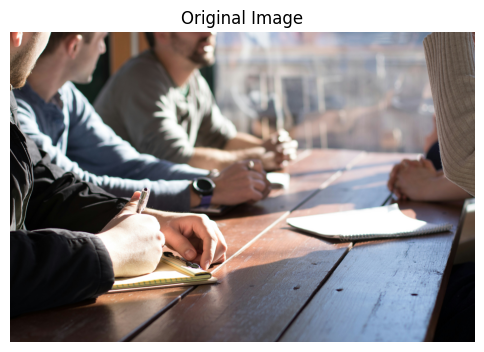

In [3]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread(list(uploaded.keys())[0])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()

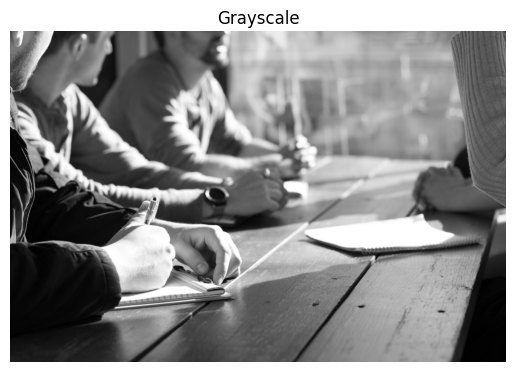

In [4]:
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis("off")
plt.show()

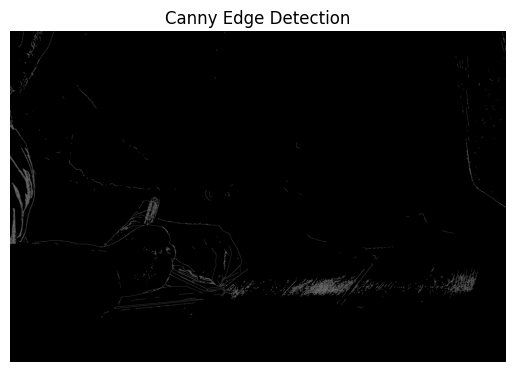

In [5]:
edges = cv2.Canny(gray, 80, 180)

plt.imshow(edges, cmap='gray')
plt.title("Canny Edge Detection")
plt.axis("off")
plt.show()

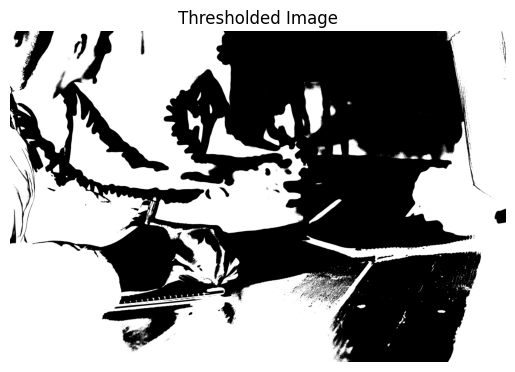

In [6]:
_, thresh = cv2.threshold(gray, 130, 255, cv2.THRESH_BINARY_INV)

plt.imshow(thresh, cmap='gray')
plt.title("Thresholded Image")
plt.axis("off")
plt.show()

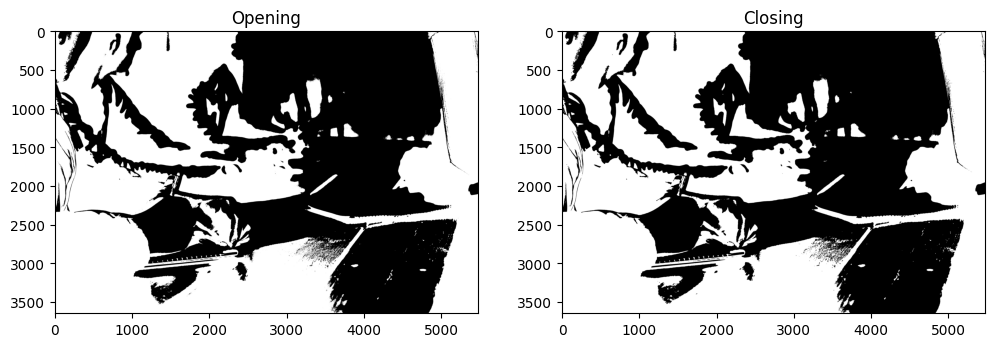

In [7]:
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))

opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(opening,cmap='gray')
plt.title("Opening")

plt.subplot(1,2,2)
plt.imshow(closing,cmap='gray')
plt.title("Closing")

plt.show()

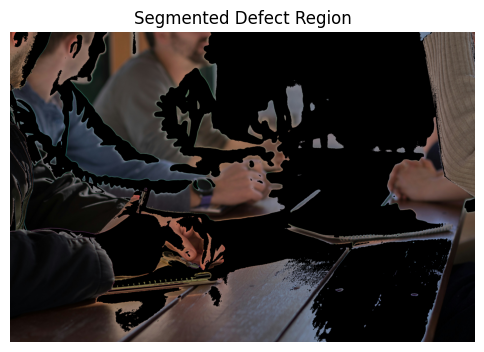

In [8]:
segmented = cv2.bitwise_and(image, image, mask=closing)

plt.figure(figsize=(6,6))
plt.imshow(segmented)
plt.title("Segmented Defect Region")
plt.axis("off")
plt.show()

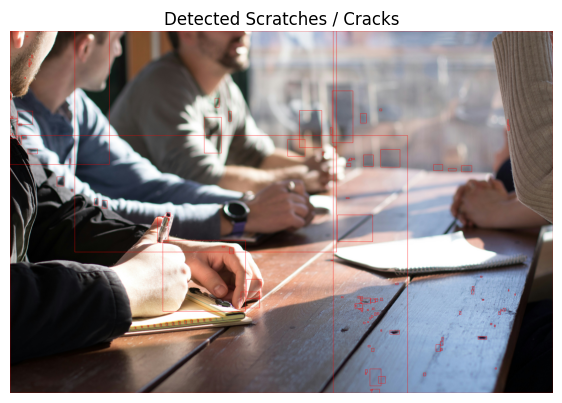

In [9]:
contours, _ = cv2.findContours(closing, cv2.RETR_EXTERNAL,
                               cv2.CHAIN_APPROX_SIMPLE)

output = image.copy()

for cnt in contours:
    area = cv2.contourArea(cnt)

    if area > 50:
        x,y,w,h = cv2.boundingRect(cnt)
        cv2.rectangle(output,(x,y),(x+w,y+h),(255,0,0),2)

plt.figure(figsize=(7,7))
plt.imshow(output)
plt.title("Detected Scratches / Cracks")
plt.axis("off")
plt.show()

In [10]:
count = 0

for cnt in contours:
    if cv2.contourArea(cnt) > 50:
        count += 1

print("Total Defects Detected:", count)

Total Defects Detected: 123
